## Goal : To build functions that can help visualize "bad" qubits for DD

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator

In [ ]:
def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler


def pm_for_backend(bknd, opt_level, seed=42069, scheduling_method="alap"):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=scheduling_method)
    return pms


def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        # summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq="XX"):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    # Default Sequence
    sequenece = [XGate(), XGate()]

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    target = backend.target
    ## Prepare a preset passmanager for backend optimization_level=3
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)

    if scheduling_method == "alap":
        pm.scheduling.append(ALAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    elif scheduling_method == "asap":
        pm.scheduling.append(ASAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
        
    return pm




def transpile_for_dd(circuit, dd_pm, backend):
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    return isa_dd_circuit
    



def get_fidelity_for_circuit(ideal, simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated] + dd_counts_list:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]




def summarize_backend(backend):
    """Return a structured snapshot of backend properties for an online IBMBackend."""
    try:
        config = backend.configuration()
    except Exception:
        config = None

    try:
        props = backend.properties()
    except Exception:
        props = None

    num_qubits = getattr(backend, "num_qubits", None)
    if callable(num_qubits):
        num_qubits = num_qubits()

    dt = None
    if config and hasattr(config, "dt"):
        dt = getattr(config, "dt", None)
    elif getattr(backend, "dt", None):
        dt = backend.dt
    elif getattr(getattr(backend, "target", None), "dt", None):
        dt = backend.target.dt

    granularity = None
    if config and getattr(config, "timing_constraints", None):
        granularity = config.timing_constraints.get("granularity")
    if granularity is None and getattr(getattr(backend, "target", None), "granularity", None):
        granularity = backend.target.granularity

    summary = {
        "backend_name": getattr(backend, "name", lambda: str(backend)),
        "num_qubits": num_qubits or (getattr(config, "num_qubits", None) if config else None),
        "basis_gates": [],
        "supported_instructions": [],
        "coupling_map": None,
        "qubit_properties": [],
        "gate_parameters": [],
        "last_update": None,
        "dt": dt,
        "granularity": granularity,
    }

    target = getattr(backend, "target", None)
    if config and getattr(config, "basis_gates", None):
        summary["basis_gates"] = list(config.basis_gates)
    elif target is not None:
        summary["basis_gates"] = list(target.operations)

    if target is not None:
        summary["supported_instructions"] = list(target.operations)

    coupling_map = None
    if config and getattr(config, "coupling_map", None):
        coupling_map = [list(edge) for edge in config.coupling_map]
    elif getattr(backend, "coupling_map", None):
        cm = backend.coupling_map
        if cm:
            coupling_map = [list(edge) for edge in cm]
    elif target is not None:
        try:
            target_map = target.build_coupling_map()
            if target_map:
                coupling_map = [list(edge) for edge in target_map.get_edges()]
        except Exception:
            pass
    summary["coupling_map"] = coupling_map

    if props:
        props_dict = props.to_dict()
        for qubit_index, qubit_props in enumerate(props_dict.get("qubits", [])):
            values = {entry["name"]: entry["value"] for entry in qubit_props}
            readout_error = values.get("readout_error")
            if readout_error is None and {"prob_meas0_prep1", "prob_meas1_prep0"}.issubset(values):
                readout_error = (values["prob_meas0_prep1"] + values["prob_meas1_prep0"]) / 2

            summary["qubit_properties"].append({
                "qubit": qubit_index,
                "t1": values.get("T1"),
                "t2": values.get("T2"),
                "frequency": values.get("frequency"),
                "readout_error": readout_error,
            })

        for gate in props_dict.get("gates", []):
            params = {param["name"]: param["value"] for param in gate.get("parameters", [])}
            summary["gate_parameters"].append({
                "gate": gate.get("gate"),
                "qubits": gate.get("qubits"),
                "gate_error": params.get("gate_error"),
                "gate_length": params.get("gate_length"),
            })

        summary["last_update"] = props_dict.get("last_update_date")

    return summary

In [3]:
service = QiskitRuntimeService()
torino = service.backend("ibm_torino")
torino

management.get:WARNING:2025-12-08 01:24:48,003: Loading default saved account


<IBMBackend('ibm_torino')>

In [4]:
torino.qubit_properties(0)

QubitProperties(t1=0.0001317864878097547, t2=0.000250936365777871, frequency=None)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from qiskit import transpile, QuantumCircuit
from qiskit.visualization import plot_gate_map


def get_backend_metrics(backend):
    """
    Extracts T1, T2, and Gate Errors (Coupling Quality) from the backend.
    """
    target = backend.target
    num_qubits = backend.num_qubits
    
    # 1. Extract T1 and T2 for every qubit
    t1_times    = []
    t2_times    = []
    DD_qubits   = {"good": [], "bad": [], "ugly": []}
    gate_errors = {'x':[], 'sx':[], 'measure':[], 'rz':[]}
    
    
    for i in range(num_qubits):

        ## Separate qubits accoriding to DD fitness
        try:
            # Get t1, t2 values (values are usually in seconds)
            props = backend.qubit_properties(i)
            t1_times.append(props.t1)
            t2_times.append(props.t2)

            ## Getting all the gate error each index of the list corresponds to qubit number
            for gate in list(gate_errors.keys()):
                gate_errors[gate].append(target[gate][(i,)].error)

            ## The Ugly
            if 2.5*props.t1 < props.t2:
                DD_qubits['ugly'].append(i)

            ## The bad : Currently defining randomly but shall make better later...
            elif 2.5*props.t1 >= props.t2 and 1.5*props.t1 <= props.t2:
                DD_qubits['bad'].append(i)

            ## The Good
            else:
                DD_qubits['good'].append(i)

        except:
            t1_times.append(0)
            t2_times.append(0)

        
    gate_errors['cz'] = dict()
    # 2. Extract Coupling Error (Proxy for ZZ/Connection Quality)
    # We look for the 'ecr' or 'cx' gate error between coupled pairs
    coupling_map = target.build_coupling_map()
    
    
    # Find the dominant 2-qubit gate (usually 'ecr' or 'cz')
    two_q_gate = 'ecr' if 'ecr' in target.operation_names else 'cz'
    
    for edge in coupling_map:
        try:
            # Get error rate for the specific edge
            props = target[two_q_gate].get(edge)
            error = props.error if props else 1.0
            gate_errors['cz'][tuple(edge)] = error
        except:
            gate_errors['cz'][tuple(edge)] = 1.0

    return {
        "t1": np.array(t1_times),
        "t2": np.array(t2_times),
        "gate_errors": gate_errors,
        "coupling_map": coupling_map,
        "DD_qubits":DD_qubits
        }

# Initialize a backend (Replace this with your real service.backend("ibm_brisbane"))
torino = service.backend("ibm_torino")
metrics = get_backend_metrics(torino)

print(f"Extracted data for {torino.name}:")
print(f"Avg T1: {np.mean(metrics['t1'])*1e6:.2f} µs")
print(f"Avg T2: {np.mean(metrics['t2'])*1e6:.2f} µs")

# print(f"Avg Coupling Error: {np.mean(list(metrics['coupling_errors'].values())):.4f}")

Extracted data for ibm_torino:
Avg T1: 167.17 µs
Avg T2: 131.74 µs


In [28]:
def get_backend_map_with_circuit(backend_metrics, circuit, backend):
    ## Buliding colormap for qubits and connections
    qubit_color = []
    for i in range(len(backend_metrics['t1'])):
        if i in backend_metrics['DD_qubits']['ugly']:
            qubit_color.append("black")
        elif i in backend_metrics['DD_qubits']['bad']:
            qubit_color.append("orange") 
        else:
            qubit_color.append("grey") 
    line_color = []
    for e in backend_metrics["coupling_map"].get_edges():
        line_color.append("black") 
    
    ## Now for the circuit qubits
    circuit_qubits = circuit.layout.final_index_layout()

    for qubit in circuit_qubits:
        try:
            if qubit in backend_metrics['DD_qubits']['bad'] or qubit in backend_metrics['DD_qubits']['ugly']:
                qubit_color[qubit] = "#973018"
                
            else:
                qubit_color[qubit] = "#239A47"

        except IndexError:
            print("Your circuit contains qubits not on the backend. Recheck circuit.layout for more info")

        
        
    return plot_gate_map(backend, qubit_color=qubit_color, line_color=line_color, qubit_size=50, font_size=25, figsize=(14,14))

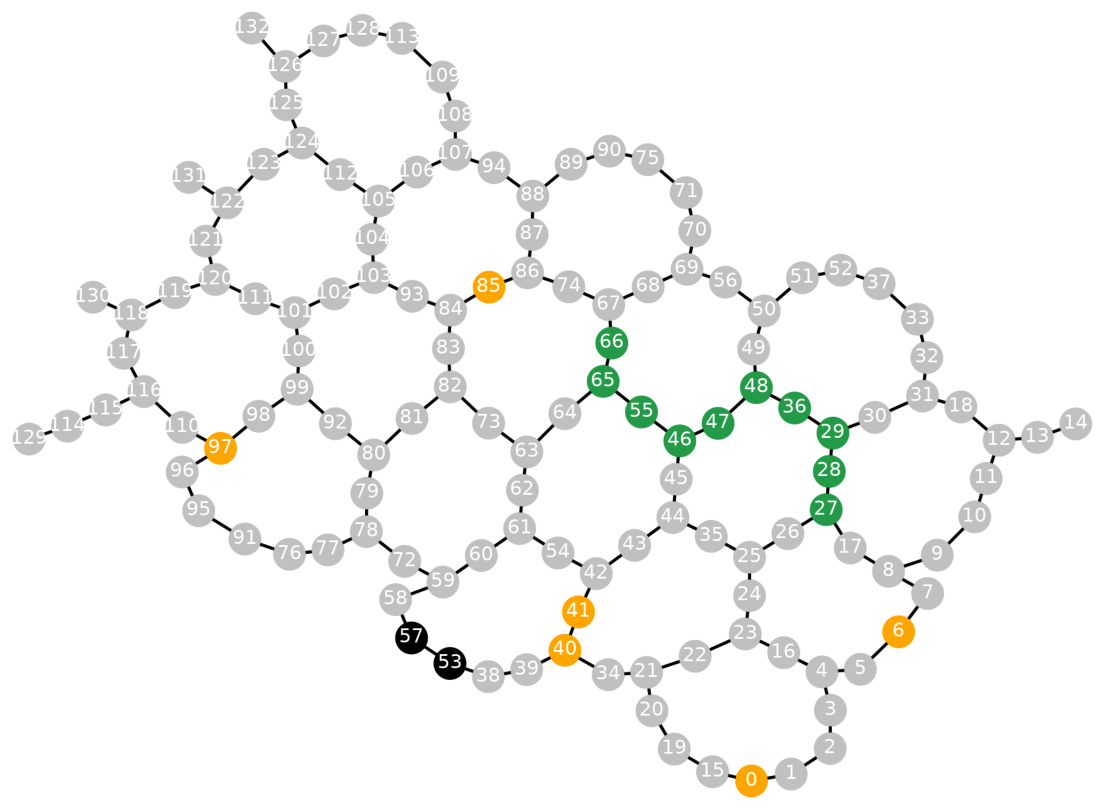

In [29]:
circuit = prepare_ghz(10)

isa_circuit = pm_for_backend(torino, opt_level=3, seed=42069).run(circuit)

get_backend_map_with_circuit(metrics, isa_circuit, torino)

In [54]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator


In [ ]:
from qiskit.transpiler.passes.scheduling import ContextAwareDynamicalDecoupling
from qiskit.circuit.library import XGate, YGate
from qiskit.circuit.equivalence_library import SessionEquivalenceLibrary
from qiskit.transpiler.passes import BasisTranslator
from qiskit_aer import AerSimulator
from qiskit import transpile

service = QiskitRuntimeService()
marrakesh = service.backend("ibm_marrakesh")
shots = 4096  # consider scaling with qubit count if variance becomes an issue

dd_sequences = {
    "xx": [XGate(), XGate()],
    "xpxm": [XGate(), XGate().inverse()],
    "xy": [XGate(), YGate()],
}

# Extend prepare_dd_pm to accept XY
def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq="XX"):
    sequence = dd_sequences.get(seq.lower())
    if sequence is None:
        raise ValueError(f"Unknown DD sequence {seq}")
    target = backend.target
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)
    schedule_pass = ALAPScheduleAnalysis if scheduling_method == "alap" else ASAPScheduleAnalysis
    pm.scheduling.append(schedule_pass(target=target))
    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequence))
    return pm

def transpile_xy_dd(circuit: QuantumCircuit, backend: Backend, scheduling_method="alap"):
    """Translate Y to the backend basis then insert XY DD."""
    translate = BasisTranslator(SessionEquivalenceLibrary, backend.target)
    translated = PassManager([translate]).run(circuit)
    xy_pm = prepare_dd_pm(backend, scheduling_method=scheduling_method, seq="XY")
    return xy_pm.run(translated)

def transpile_context_aware_dd(circuit: QuantumCircuit, backend: Backend, seq_key: str, scheduling_method="alap"):
    """Context-aware DD with the chosen sequence."""
    sequence = dd_sequences[seq_key]
    target = backend.target
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069, scheduling_method=scheduling_method)
    schedule_pass = ALAPScheduleAnalysis if scheduling_method == "alap" else ASAPScheduleAnalysis
    pm.scheduling.append(schedule_pass(target=target))
    # qiskit versions differ on the signature; try passing sequence, else fall back
    try:
        cadd_pass = ContextAwareDynamicalDecoupling(target=target, dd_sequence=sequence)
    except TypeError:
        cadd_pass = ContextAwareDynamicalDecoupling(target=target)
    pm.scheduling.append(cadd_pass)
    return pm.run(circuit)

def aer_counts(circuit: QuantumCircuit, backend: Backend = None, shots: int = shots):
    """Helper to get counts; when backend is provided we mimic its noise."""
    sim = AerSimulator.from_backend(backend) if backend else AerSimulator()
    compiled = transpile(circuit, sim)
    return sim.run(compiled, shots=shots).result().get_counts()

def build_pub_for_qubit(num_qubits: int):
    """Prepare all variants for GHZ and echo-GHZ."""
    pubs = []
    for builder in (prepare_ghz, prepare_echo_ghz_with_xs):
        circ = builder(num_qubits)
        isa_no_dd = pm_for_backend(marrakesh, opt_level=3, seed=42069, scheduling_method="alap").run(circ)

        dd_variants = [
            prepare_dd_pm(marrakesh, seq="XX").run(circ),
            prepare_dd_pm(marrakesh, seq="XpXm").run(circ),
            transpile_xy_dd(circ, marrakesh, scheduling_method="alap"),
            transpile_context_aware_dd(circ, marrakesh, "xx", scheduling_method="alap"),
            transpile_context_aware_dd(circ, marrakesh, "xpxm", scheduling_method="alap"),
            transpile_context_aware_dd(circ, marrakesh, "xy", scheduling_method="alap"),
        ]

        pubs.append([isa_no_dd, *dd_variants])
    return pubs  # [[no-dd, xx, xpxm, xy, caxx, caxpxm, caxy] for GHZ, same for echo]



In [ ]:
# Build pub_dict keyed by qubit count
qubit_sizes = [7, 9, 11]  # adjust as needed
pub_dict = {n: build_pub_for_qubit(n) for n in qubit_sizes}

# Batch execution on hardware
with Batch(backend=marrakesh) as batch:
    sampler = naked_sampler(mode=batch, shots=shots)
    flat_pubs = [c for pub in pub_dict.values() for subpub in pub for c in subpub]
    job = sampler.run(flat_pubs)
    job_id = job.job_id()
    print(f"submitted batch job: {job_id}")
    dd_counts_flat = [dist.binary_probabilities() for dist in job.result()]

# Re-split results back into the pub_dict structure
idx = 0
dd_counts = {}
for n in qubit_sizes:
    dd_counts[n] = []
    for _ in range(2):  # GHZ + echo
        counts_list = dd_counts_flat[idx : idx + 7]
        dd_counts[n].append(counts_list)  # same order as build_pub_for_qubit
        idx += 7

# Hellinger fidelities
fidelity_summary = {}
for n in qubit_sizes:
    fidelity_summary[n] = []
    for subpub_idx, pub_counts in enumerate(dd_counts[n]):
        base_circ = (prepare_ghz if subpub_idx == 0 else prepare_echo_ghz_with_xs)(n)
        ideal_counts = aer_counts(base_circ, backend=None, shots=shots)
        simulated_counts = aer_counts(base_circ, backend=marrakesh, shots=shots)
        fidelity_summary[n].append(
            get_fidelity_for_circuit(ideal_counts, simulated_counts, pub_counts)
        )

fidelity_summary  # [[[H_sim, H_noDD, H_xx, ...], [H_noDD_vs_sim, ...]] for each circuit per qubit count]
